<a href="https://colab.research.google.com/github/Shifali1094/stance-detection/blob/main/notebooks/bertweet_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NLP Assignment 3 : Stance Detection with BERTweet**

## **1. Setup & Imports**
*Mount Drive, install dependencies, import libraries.*


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# Install libraries
!pip install -q transformers datasets evaluate accelerate emoji vncorenlp
!git clone https://github.com/Shifali1094/stance-detection.git

  Preparing metadata (setup.py) ... done
fatal: destination path 'stance-detection' already exists and is not an empty directory.


In [3]:
# Imports
import pandas as pd
import numpy as np
import torch
from torch import nn
from transformers import Trainer
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datasets import Dataset
from transformers import AutoTokenizer, TrainingArguments, AutoModelForSequenceClassification, DataCollatorWithPadding
import matplotlib.pyplot as plt
from scipy.special import softmax as scipy_softmax


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

## **2. Data Preparation**

### **2.1. Load Dataset**

In [ ]:
# Detect environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Set project root
if IN_COLAB:
    PROJECT_ROOT = Path("/content/stance-detection")
else:
    PROJECT_ROOT = Path.cwd().parent

print(f"Running in Colab: {IN_COLAB}")
print(f"Project root: {PROJECT_ROOT}")

TEXT_COL = "text"
LABEL_COL = "label"

train_df = pd.read_csv(PROJECT_ROOT / "train.csv")
val_df   = pd.read_csv(PROJECT_ROOT / "val.csv")
test_df  = pd.read_csv(PROJECT_ROOT / "test.csv")

train_df = train_df[[TEXT_COL, LABEL_COL]].dropna()
val_df   = val_df[[TEXT_COL, LABEL_COL]].dropna()
test_df  = test_df[[TEXT_COL, LABEL_COL]].dropna()

train_df[TEXT_COL] = train_df[TEXT_COL].astype(str)
val_df[TEXT_COL]   = val_df[TEXT_COL].astype(str)
test_df[TEXT_COL]  = test_df[TEXT_COL].astype(str)

print(train_df.head())

Running in Colab: True
Project root: /content/stance-detection
                                                text  label
0  Atheism [SEP] dear lord thank u for all of ur ...      2
1  Atheism [SEP] blessed are the peacemakers, for...      2
2  Atheism [SEP] i am not conformed to this world...      2
3  Atheism [SEP] salah should be prayed with #foc...      2
4  Atheism [SEP] papa god, i pray that you shower...      2


### **2.2. Encode Labels**

In [5]:
# Label encoding

labels = sorted(train_df[LABEL_COL].unique().tolist())

# Convert labels to normal Python values / strings
labels = [str(label) for label in labels]

train_df[LABEL_COL] = train_df[LABEL_COL].astype(str)
val_df[LABEL_COL] = val_df[LABEL_COL].astype(str)
test_df[LABEL_COL] = test_df[LABEL_COL].astype(str)

label2id = {label: int(i) for i, label in enumerate(labels)}
id2label = {int(i): str(label) for label, i in label2id.items()}

train_df["labels"] = train_df[LABEL_COL].map(label2id).astype(int)
val_df["labels"] = val_df[LABEL_COL].map(label2id).astype(int)
test_df["labels"] = test_df[LABEL_COL].map(label2id).astype(int)

print("Labels:", label2id)
print(train_df["labels"].value_counts())

Labels: {'0': 0, '1': 1, '2': 2}
labels
2    1143
1     534
0     483
Name: count, dtype: int64


### **2.3. Convert to Hugging Face Dataset**

In [6]:
train_dataset = Dataset.from_pandas(
    train_df[[TEXT_COL, "labels"]]
)

val_dataset = Dataset.from_pandas(
    val_df[[TEXT_COL, "labels"]]
)

test_dataset = Dataset.from_pandas(
    test_df[[TEXT_COL, "labels"]]
)

### **2.4. Tokenise**

In [7]:
MODEL_NAME = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    normalization=True
)

def tokenize_function(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/2160 [00:00<?, ? examples/s]

Map:   0%|          | 0/359 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

## **3. Model Setup**

### **3.1. Load BERTweet**

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

### **3.2. Define Metrics**

In [9]:
def compute_metrics(eval_pred):

    logits, y_true = eval_pred

    y_pred = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

## **4. Training**

### **4.1. Training Arguuments**

In [10]:
training_args = TrainingArguments(
    output_dir="./bertweet_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=25,
    report_to="none",
    seed=42
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### **4.2. Class Weights & Weighted Trainer**

In [11]:
# Compute inverse-frequency weights from training labels
class_counts = train_df["labels"].value_counts().sort_index().values
print("Class counts:", class_counts)

# Inverse frequency, then normalise so they sum to num_classes
weights = len(class_counts) / (class_counts * class_counts.sum())
class_weights_tensor = torch.tensor(weights, dtype=torch.float)
print("Class weights:", class_weights_tensor)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device)
        )
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Weighted trainer created, class weights applied")

Class counts: [ 483  534 1143]
Class weights: tensor([2.8755e-06, 2.6009e-06, 1.2151e-06])
Weighted trainer created, class weights applied


### **4.3. Run Training**

In [12]:
train_result = trainer.train()

print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.032826,0.986675,0.451253,0.508039,0.585102,0.439584
2,0.833232,0.825052,0.545961,0.594384,0.609511,0.549099
3,0.741083,0.808280,0.540390,0.605321,0.640346,0.551412
4,0.648987,0.771626,0.643454,0.637221,0.648949,0.606309
5,0.599738,0.767337,0.623955,0.636793,0.650509,0.601861


TrainOutput(global_step=675, training_loss=0.7969640420984339, metrics={'train_runtime': 162.4558, 'train_samples_per_second': 66.48, 'train_steps_per_second': 4.155, 'total_flos': 377403308553600.0, 'train_loss': 0.7969640420984339, 'epoch': 5.0})


## **5. Evaluation**

### **5.1. Test Set Results**

In [13]:
test_results = trainer.evaluate(test_dataset)

print(test_results)

{'eval_loss': 0.8308448195457458, 'eval_accuracy': 0.5833333333333334, 'eval_macro_precision': 0.5768567093500754, 'eval_macro_recall': 0.6506358742546587, 'eval_macro_f1': 0.5678960053776221, 'eval_runtime': 3.0182, 'eval_samples_per_second': 357.826, 'eval_steps_per_second': 22.53, 'epoch': 5.0}


### **5.2. Classification Report**

In [14]:
predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

target_names = [
    str(id2label[i])
    for i in range(len(labels))
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.34      0.78      0.47       181
           1       0.54      0.66      0.59       195
           2       0.86      0.51      0.64       704

    accuracy                           0.58      1080
   macro avg       0.58      0.65      0.57      1080
weighted avg       0.71      0.58      0.60      1080



## **6. Visualisation**

### **6.1. Per-class Precision / Recall / F1**

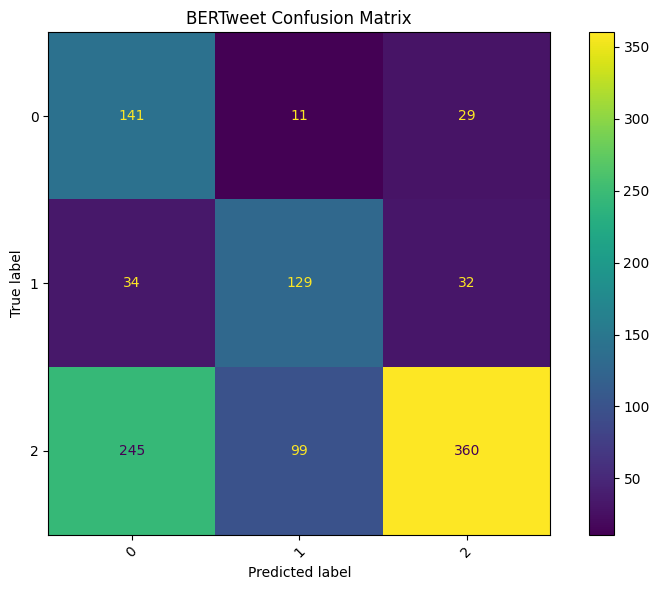

In [15]:
cm = confusion_matrix(
    y_true,
    y_pred
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
fig, ax = plt.subplots(
    figsize=(8, 6)
)
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title(
    "BERTweet Confusion Matrix"
)
plt.tight_layout()
plt.savefig(
    "bertweet_confusion_matrix.png",
    dpi=300
)
plt.show()

In [31]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})
CLASS_NAMES = ["FAVOR", "NONE", "AGAINST"]
COLORS = ["#378ADD", "#888780", "#D85A30"]


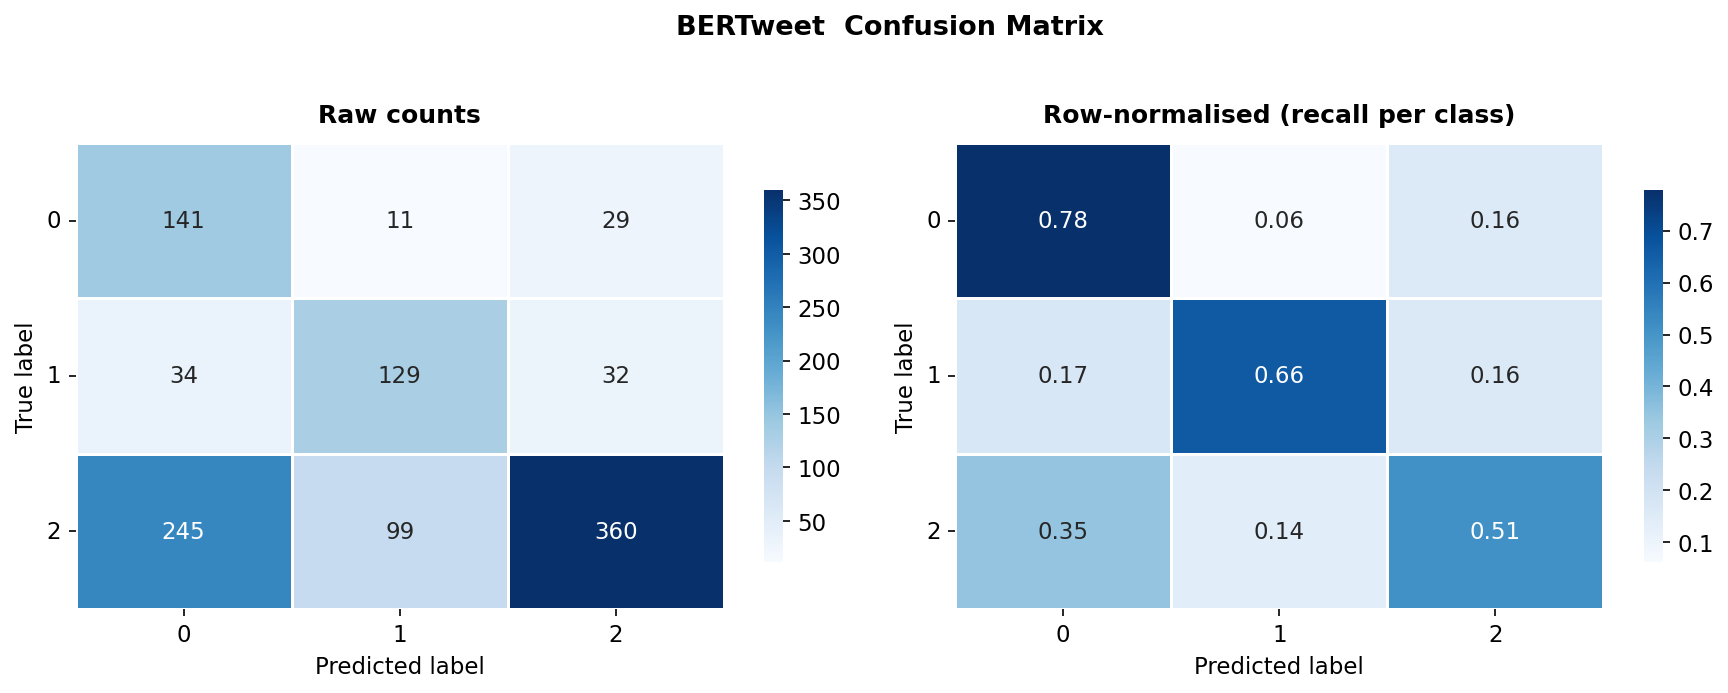

In [17]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ["d", ".2f"],
    ["Raw counts", "Row-normalised (recall per class)"]
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.8}, ax=ax
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("BERTweet  Confusion Matrix", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### **6.1. Per-class Precision / Recall/ F1**

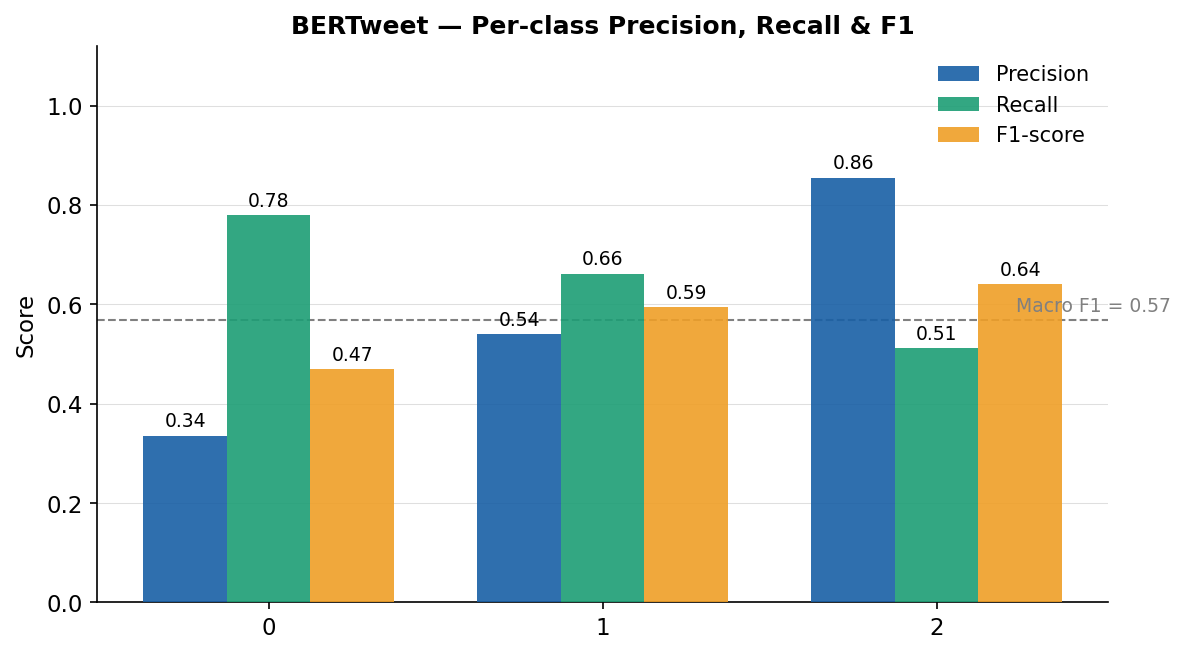

In [18]:
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics   = ["precision", "recall", "f1-score"]
x         = np.arange(len(CLASS_NAMES))
bar_w     = 0.25
bar_color = ["#185FA5", "#1D9E75", "#EF9F27"]   # blue, teal, amber

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (metric, color) in enumerate(zip(metrics, bar_color)):
    vals = [report[cls][metric] for cls in CLASS_NAMES]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=metric.capitalize(),
                  color=color, alpha=0.9, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{v:.2f}", ha="center", va="bottom", fontsize=9
        )

ax.set_xticks(x + bar_w)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))
ax.legend(frameon=False, fontsize=10)
ax.set_title("BERTweet — Per-class Precision, Recall & F1", fontsize=12, fontweight="bold")
ax.axhline(report["macro avg"]["f1-score"], color="gray", linewidth=1,
           linestyle="--", label="Macro F1")
ax.text(len(CLASS_NAMES) - 0.05,
        report["macro avg"]["f1-score"] + 0.01,
        f'Macro F1 = {report["macro avg"]["f1-score"]:.2f}',
        ha="right", va="bottom", color="gray", fontsize=9)
ax.grid(axis="y", linewidth=0.5, alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

### **6.2. Training & Validation Loss Curve**

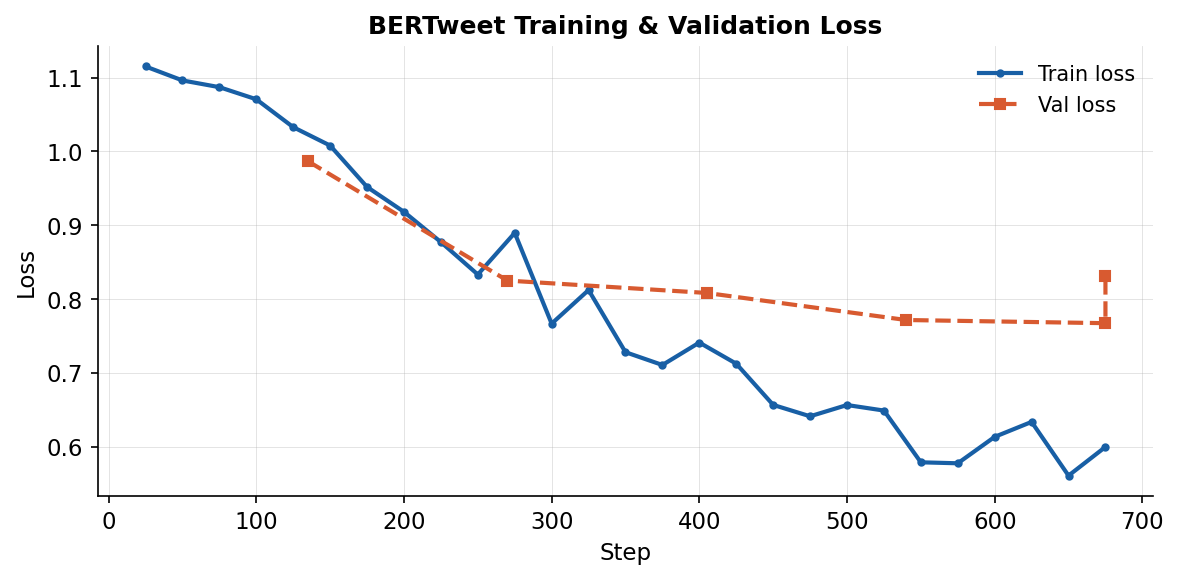

In [19]:
log_history = trainer.state.log_history

train_steps  = [e["step"] for e in log_history if "loss" in e]
train_losses = [e["loss"] for e in log_history if "loss" in e]
eval_steps   = [e["step"] for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

if train_steps:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_steps, train_losses, label="Train loss",
            color="#185FA5", linewidth=2, marker="o", markersize=3)
    if eval_steps:
        ax.plot(eval_steps, eval_losses, label="Val loss",
                color="#D85A30", linewidth=2, marker="s", markersize=5,
                linestyle="--")
    ax.set_xlabel("Step", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title("BERTweet Training & Validation Loss", fontsize=12, fontweight="bold")
    ax.legend(frameon=False, fontsize=10)
    ax.grid(linewidth=0.4, alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("No training loss logs found skipping loss curve.")

### **6.3. ROC Curves**

In [20]:
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

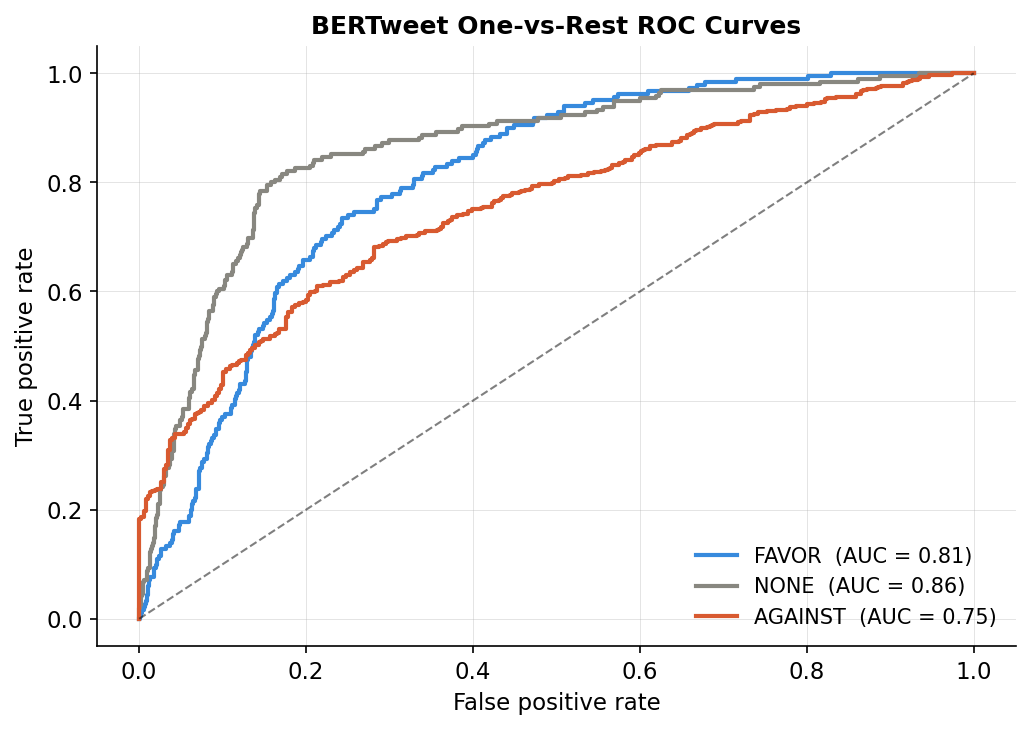

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.special import softmax as scipy_softmax

try:
    probs = scipy_softmax(predictions.predictions, axis=1)
    y_true_bin = label_binarize(y_true, classes=list(range(len(labels))))

    fig, ax = plt.subplots(figsize=(7, 5))
    for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls}  (AUC = {roc_auc:.2f})",
                color=color, linewidth=2)

    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
    ax.set_xlabel("False positive rate", fontsize=11)
    ax.set_ylabel("True positive rate", fontsize=11)
    ax.set_title("BERTweet One-vs-Rest ROC Curves", fontsize=12, fontweight="bold")
    ax.legend(frameon=False, fontsize=10)
    ax.grid(linewidth=0.4, alpha=0.4)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"ROC curves skipped: {e}")

## **7. Save Outputs**

### **7.1. Predictions CSV**

In [22]:
# Save predictions

test_output = test_df.copy()

test_output["predicted_label_id"] = y_pred

test_output["predicted_label"] = [
    id2label[int(i)]
    for i in y_pred
]

test_output["true_label"] = [
    id2label[int(i)]
    for i in y_true
]

test_output.to_csv(
    "bertweet_test_predictions.csv",
    index=False
)

print(
    "Predictions saved successfully"
)

test_output.head()

Predictions saved successfully


,text,label,labels,predicted_label_id,predicted_label,true_label
0,Atheism [SEP] he who exalts himself shall be h...,2,2,2,2,2
1,Atheism [SEP] rt : i remove nehushtan -previou...,2,2,2,2,2
2,Atheism [SEP] i have sought the truth of my so...,2,2,2,2,2
3,Atheism [SEP] #god is utterly powerless withou...,2,2,2,2,2
4,Atheism [SEP] miracles of #multiculturalism mi...,2,2,1,1,2


### **7.2. Model & Tokenizer**

In [23]:
# Save final model and tokenizer

trainer.save_model(
    "./final_bertweet_model"
)

tokenizer.save_pretrained(
    "./final_bertweet_model"
)

print(
    "Model and tokenizer saved successfully"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully
